In [53]:
!pip install openimages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 kB 7.6 MB/s eta 0:00:00


In [54]:
import os
from google.colab import drive
from openimages.download import download_dataset

In [55]:
classes = ["banana", "orange", "strawberry"]

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path = "/content/drive/MyDrive/openImages"
os.makedirs(save_path, exist_ok=True)

number_for_samples = 350
download_dataset(save_path, classes, limit=number_for_samples)


In [5]:
classesId = [954, 950, 949]

In [6]:
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.io import read_image
from torchvision import datasets
import torchvision
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
from skimage import io
from skimage.transform import resize
import glob
from PIL import Image

In [7]:
scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

In [8]:
def read_img(file_name):
    img = Image.open(file_name)
    t_img = Variable(normalize(to_tensor(scaler(img))).unsqueeze(0))
    return t_img.float()

In [9]:
transform = transforms.Compose([
    torchvision.transforms.Resize((224,224)),
    torchvision.transforms.ColorJitter(hue=.05, saturation=.05),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(20),
    transforms.ToTensor()
])

In [10]:
def use_device():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    return device

In [11]:
weights = ResNet50_Weights.DEFAULT
device = use_device()
model = torchvision.models.resnet50(weights=weights).to(device)
preprocess = weights.transforms()

Using device: cpu


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 261MB/s]


In [20]:
image = Image.open('/content/drive/MyDrive/openImages/banana/0a7e071b30e23d13.jpg')

output = model(transform(image).unsqueeze(0).to(device))
output = output.squeeze().cpu()

probabilities = torch.sigmoid(output).cpu().detach().numpy()
for class_name, class_idx in zip(classes, classesId):
    class_prob = probabilities[class_idx]
    print(f"Class: {class_name}, Probability: {class_prob * 100:.5f}%")

Class: banana, Probability: 64.64154%
Class: orange, Probability: 46.78169%
Class: strawberry, Probability: 47.91898%


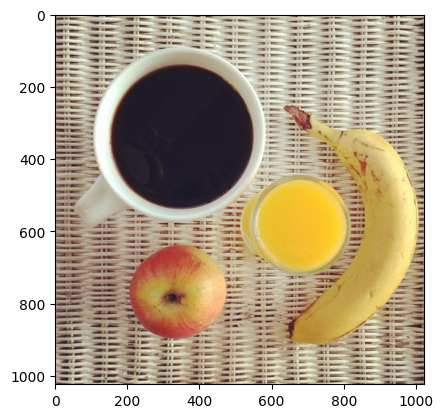

In [21]:
image = Image.open('drive/MyDrive/openImages/banana/100940397939f11e.jpg')
plt.imshow(image)
plt.show()

In [ ]:
os.listdir('/content/drive/MyDrive/openImages')

['strawberry', 'orange', 'banana']

In [22]:
class CustomDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform

        self.classes = ["banana", "orange", "strawberry"]
        self.class_to_label = {cls: i for i, cls in enumerate(self.classes)}
        print(self.class_to_label)

        self.files = []
        self.labels = []

        for cls in self.classes:
            class_files = glob.glob(os.path.join(self.images_dir, cls, "*.jpg"))
            self.files.extend(class_files)
            self.labels.extend([self.class_to_label[cls]] * len(class_files))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
      file_path = self.files[i]
      img = Image.open(file_path).convert("RGB")

      if self.transform:
          img = self.transform(img)

      y = self.labels[i]

      return img, y


In [23]:
dataset = CustomDataset("drive/MyDrive/openImages", transform=transform)
print(f"Total images: {len(dataset)}")

{'banana': 0, 'orange': 1, 'strawberry': 2}
Total images: 1050


In [25]:
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [26]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.numpy()

            outputs = model(images)
            probabilities = torch.sigmoid(outputs).cpu().detach().numpy()
            probabilities = probabilities[:, classesId]

            all_preds.append(probabilities)
            all_labels.append(labels)

    return np.vstack(all_preds), np.hstack(all_labels)

In [27]:
predictions, ground_truth = get_predictions(model, train_loader, device)

In [40]:
class_thresholds = {
    "banana": 0.61,
    "orange": 0.78,
    "strawberry": 0.83
}

thresholds = np.array([class_thresholds["banana"], class_thresholds["orange"], class_thresholds["strawberry"]])

predictions_thresholded = (predictions > thresholds).astype(np.float64)

num_classes = 3
TP = np.zeros(num_classes)
TN = np.zeros(num_classes)
FP = np.zeros(num_classes)
FN = np.zeros(num_classes)

for i in range(num_classes):
    TP[i] = np.sum((ground_truth == i) & (predictions_thresholded[:, i] == 1))
    TN[i] = np.sum((ground_truth != i) & (predictions_thresholded[:, i] == 0))
    FP[i] = np.sum((ground_truth != i) & (predictions_thresholded[:, i] == 1))
    FN[i] = np.sum((ground_truth == i) & (predictions_thresholded[:, i] == 0))

for i, class_name in enumerate(["banana", "orange", "strawberry"]):
    print(f"\nClass: {class_name}")
    print(f"  True Positives (TP): {TP[i]}")
    print(f"  False Negatives (FN): {FN[i]}")
    print(f"  False Positives (FP): {FP[i]}")
    print(f"  True Negatives (TN): {TN[i]}")

metrics = {}
for i, class_name in enumerate(["banana", "orange", "strawberry"]):
    accuracy = (TP[i] + TN[i]) / (TP[i] + FP[i] + TN[i] + FN[i]) if (TP[i] + FP[i] + TN[i] + FN[i]) > 0 else 0
    recall = TP[i] / (TP[i] + FN[i]) if (TP[i] + FN[i]) > 0 else 0
    precision = TP[i] / (TP[i] + FP[i]) if (TP[i] + FP[i]) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics[class_name] = {
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1-score": f1
    }

print("\nPerformance Metrics:")
for class_name, values in metrics.items():
    print(f"\nClass: {class_name}")
    for metric_name, value in values.items():
        print(f"  {metric_name}: {value:.4f}")


Class: banana
  True Positives (TP): 253.0
  False Negatives (FN): 97.0
  False Positives (FP): 183.0
  True Negatives (TN): 517.0

Class: orange
  True Positives (TP): 252.0
  False Negatives (FN): 98.0
  False Positives (FP): 36.0
  True Negatives (TN): 664.0

Class: strawberry
  True Positives (TP): 290.0
  False Negatives (FN): 60.0
  False Positives (FP): 50.0
  True Negatives (TN): 650.0

Performance Metrics:

Class: banana
  accuracy: 0.7333
  recall: 0.7229
  precision: 0.5803
  f1-score: 0.6438

Class: orange
  accuracy: 0.8724
  recall: 0.7200
  precision: 0.8750
  f1-score: 0.7900

Class: strawberry
  accuracy: 0.8952
  recall: 0.8286
  precision: 0.8529
  f1-score: 0.8406


In [51]:
def find_best_threshold(predictions, ground_truth, class_names, metric='f1'):
    best_thresholds = {}
    threshold_range = np.linspace(0, 1, 101)

    for class_idx, class_name in enumerate(class_names):
        best_threshold = 0.5
        best_score = 0

        for threshold in threshold_range:
            preds = (predictions[:, class_idx] > threshold).astype(int)
            gt = (ground_truth == class_idx).astype(int)

            TP = np.sum((gt == 1) & (preds == 1))
            TN = np.sum((gt == 0) & (preds == 0))
            FP = np.sum((gt == 0) & (preds == 1))
            FN = np.sum((gt == 1) & (preds == 0))

            accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0
            recall = TP / (TP + FN) if (TP + FN) > 0 else 0
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            score = {'accuracy': accuracy, 'recall': recall, 'precision': precision, 'f1': f1}[metric]

            if score > best_score:
                best_score = score
                best_threshold = threshold

        best_thresholds[class_name] = best_threshold

    return best_thresholds


In [52]:
best_thresholds = find_best_threshold(predictions, ground_truth, classes, metric="f1")

print("Optimal Thresholds:")
for class_name, threshold in best_thresholds.items():
    print(f"  {class_name}: {threshold:.2f}")

Optimal Thresholds:
  banana: 0.61
  orange: 0.78
  strawberry: 0.83
